<a href="https://colab.research.google.com/github/antiat/ML_stud_practice_2026_3rd_course/blob/main/Stud_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Импорт библиотек <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc
)

# Глобальный стиль графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
print('Все библиотеки успешно импортированы.')


Все библиотеки успешно импортированы.


## 2. Загрузка и первичный осмотр данных <a id='2'></a>

In [ ]:
df = pd.read_csv('stress_dataset.csv')

print(f'Размер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов')
print(f'Целевая переменная: stress_level → классы {sorted(df["stress_level"].unique())}')


Размер датасета: 10080 строк × 21 столбцов
Целевая переменная: stress_level → классы [np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
df.head(10)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,10.0,15.0,1,8.0,2.0,2,2.0,3,0.0,4,...,2,3,3.0,4,4,2.0,4,5,1,1
1,11.0,20.0,1,5.0,2.0,2,5.0,2,0.0,3,...,4,5,3.0,3,0,2.0,2,2,0,0
2,11.0,NaN,1,17.0,3.0,3,3.0,3,2.0,4,...,3,3,4.0,3,4,2.0,5,5,3,2
3,10.0,15.0,0,13.0,3.0,3,2.0,3,3.0,3,...,1,4,5.0,2,3,2.0,3,4,2,1
4,10.0,20.0,0,12.0,3.0,2,2.0,2,1.0,3,...,4,2,3.0,3,3,2.0,3,3,3,1
5,13.0,20.0,0,9.0,3.0,3,3.0,3,1.0,2,...,2,3,3.0,3,2,2.0,3,3,2,1
6,11.0,16.0,0,13.0,NaN,2,3.0,4,1.0,2,...,3,1,4.0,3,5,1.0,5,4,1,2
7,7.0,21.0,0,4.0,0.0,2,4.0,2,1.0,5,...,4,4,3.0,5,2,3.0,0,2,1,0
8,2.0,24.0,0,3.0,0.0,1,5.0,2,1.0,5,...,5,5,2.0,4,1,3.0,1,3,0,0
9,5.0,22.0,0,8.0,0.0,1,5.0,1,1.0,5,...,3,5,2.0,3,1,2.0,3,2,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 9827 non-null   float64
 1   self_esteem                   9741 non-null   float64
 2   mental_health_history         10080 non-null  int64  
 3   depression                    9925 non-null   float64
 4   headache                      9888 non-null   float64
 5   blood_pressure                10080 non-null  int64  
 6   sleep_quality                 9920 non-null   float64
 7   breathing_problem             10080 non-null  int64  
 8   noise_level                   9823 non-null   float64
 9   living_conditions             10080 non-null  int64  
 10  safety                        10080 non-null  int64  
 11  basic_needs                   10080 non-null  int64  
 12  academic_performance          10080 non-null  int64  
 13  s

In [ ]:
print('=== Статистика числовых признаков ===')
df.describe().round(2)


=== Статистика числовых признаков ===


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,9827.00,9741.00,10080.00,9925.00,9888.00,10080.00,9920.00,10080.00,9823.00,10080.00,...,10080.00,10080.00,9750.00,10080.00,10080.00,9911.00,10080.00,10080.00,10080.00,10080.00
mean,10.14,18.19,0.30,12.07,2.08,2.01,2.95,2.02,1.99,2.98,...,2.99,2.97,2.95,2.99,2.95,1.95,2.97,2.96,2.02,1.00
std,5.07,5.95,0.46,6.48,2.03,0.70,1.42,1.29,1.25,1.24,...,1.24,1.35,1.26,1.24,1.35,0.90,1.25,1.23,1.34,0.81
min,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7.00,15.00,0.00,8.00,1.00,2.00,2.00,1.00,1.00,2.00,...,2.00,2.00,2.00,2.00,2.00,1.00,2.00,2.00,1.00,0.00
50%,10.00,18.00,0.00,12.00,2.00,2.00,3.00,2.00,2.00,3.00,...,3.00,3.00,3.00,3.00,3.00,2.00,3.00,3.00,2.00,1.00
75%,13.00,21.00,1.00,16.00,3.00,2.00,4.00,3.00,3.00,4.00,...,4.00,4.00,4.00,4.00,4.00,3.00,4.00,4.00,3.00,2.00
max,60.00,100.00,1.00,80.00,50.00,3.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,3.00,5.00,5.00,5.00,2.00


In [ ]:
print('=== Распределение классов ===')
vc = df['stress_level'].value_counts().sort_index()
labels = {0: 'Низкий (0)', 1: 'Средний (1)', 2: 'Высокий (2)'}
for cls, cnt in vc.items():
    print(f'  {labels[cls]}: {cnt} ({cnt/len(df)*100:.1f}%)')


=== Распределение классов ===
  Низкий (0): 3327 (33.0%)
  Средний (1): 3421 (33.9%)
  Высокий (2): 3332 (33.1%)


## 3. Обработка пропущенных значений <a id='3'></a>

Сначала количественно оцениваем пропуски, визуализируем, затем удаляем строки с пропусками.


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Пропусков': missing, '%': missing_pct})
missing_df = missing_df[missing_df['Пропусков'] > 0].sort_values('Пропусков', ascending=False)
print(missing_df.to_string())


                Пропусков     %
self_esteem           339  3.36
study_load            330  3.27
noise_level           257  2.55
anxiety_level         253  2.51
headache              192  1.90
social_support        169  1.68
sleep_quality         160  1.59
depression            155  1.54


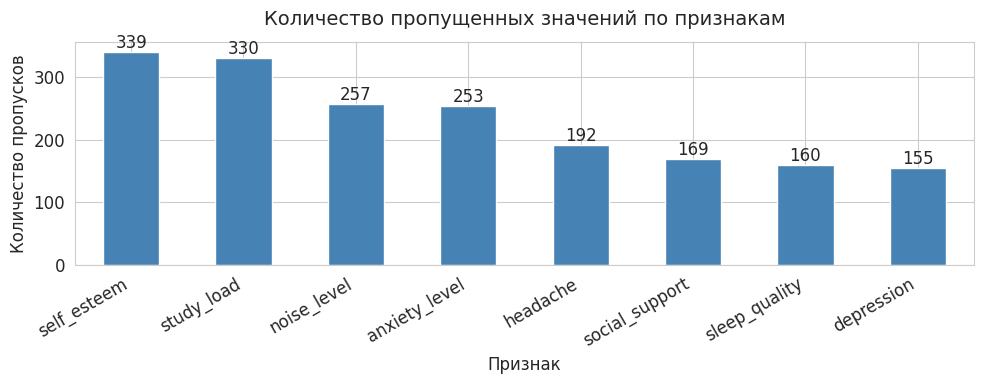

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
missing_df['Пропусков'].plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Количество пропущенных значений по признакам', fontsize=14, pad=12)
ax.set_xlabel('Признак')
ax.set_ylabel('Количество пропусков')
ax.bar_label(ax.containers[0], fmt='%d')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
df_clean = df.dropna().reset_index(drop=True)
print(f'До удаления пропусков:  {len(df):>5} строк')
print(f'После удаления пропусков: {len(df_clean):>5} строк')
print(f'Удалено: {len(df) - len(df_clean)} строк ({(len(df)-len(df_clean))/len(df)*100:.1f}%)')
df = df_clean.copy()


До удаления пропусков:  10080 строк
После удаления пропусков:  8365 строк
Удалено: 1715 строк (17.0%)


## 4. Исследовательский анализ данных (EDA) <a id='4'></a>


### 4.1 Распределение целевой переменной

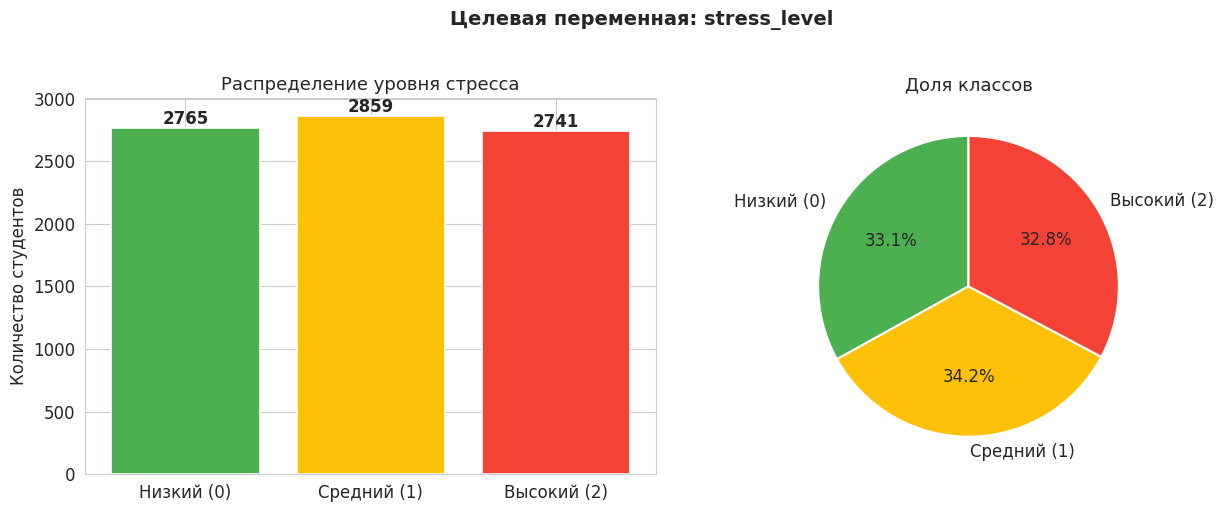


Вывод: классы сбалансированы — дополнительной стратификации при обучении не требуется.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#4CAF50', '#FFC107', '#F44336']
stress_labels = ['Низкий (0)', 'Средний (1)', 'Высокий (2)']

# countplot
counts = df['stress_level'].value_counts().sort_index()
axes[0].bar(stress_labels, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Распределение уровня стресса', fontsize=13)
axes[0].set_ylabel('Количество студентов')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# pie
axes[1].pie(counts.values, labels=stress_labels, colors=colors,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Доля классов', fontsize=13)

plt.suptitle('Целевая переменная: stress_level', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nВывод: классы сбалансированы — дополнительной стратификации при обучении не требуется.')


### 4.2 Гистограммы числовых признаков

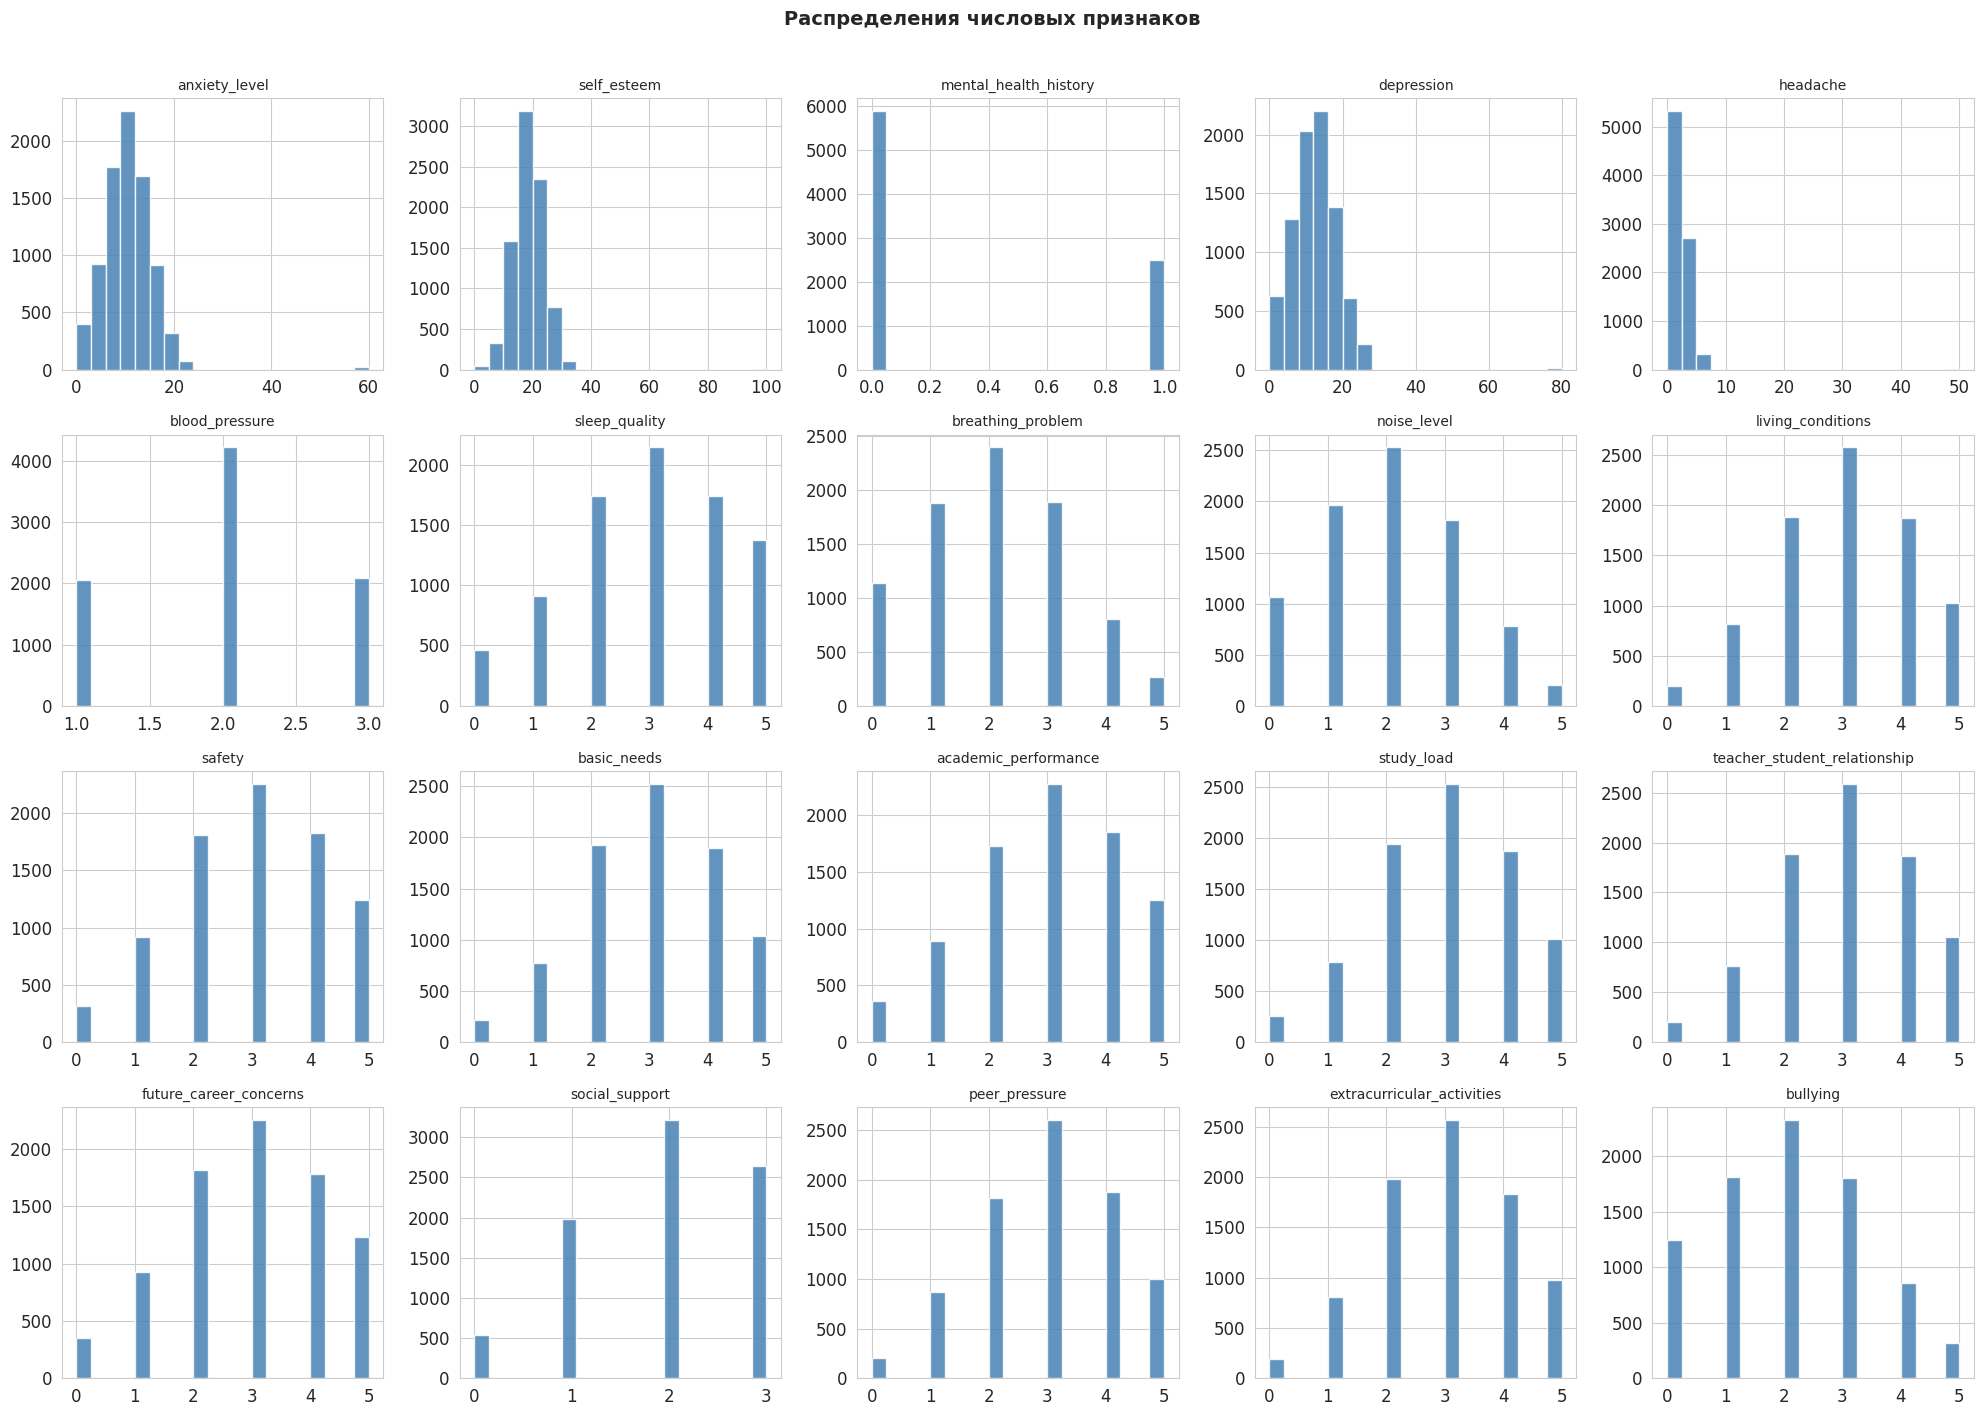

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.drop('stress_level').tolist()

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Распределения числовых признаков', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 4.3 Матрица корреляции

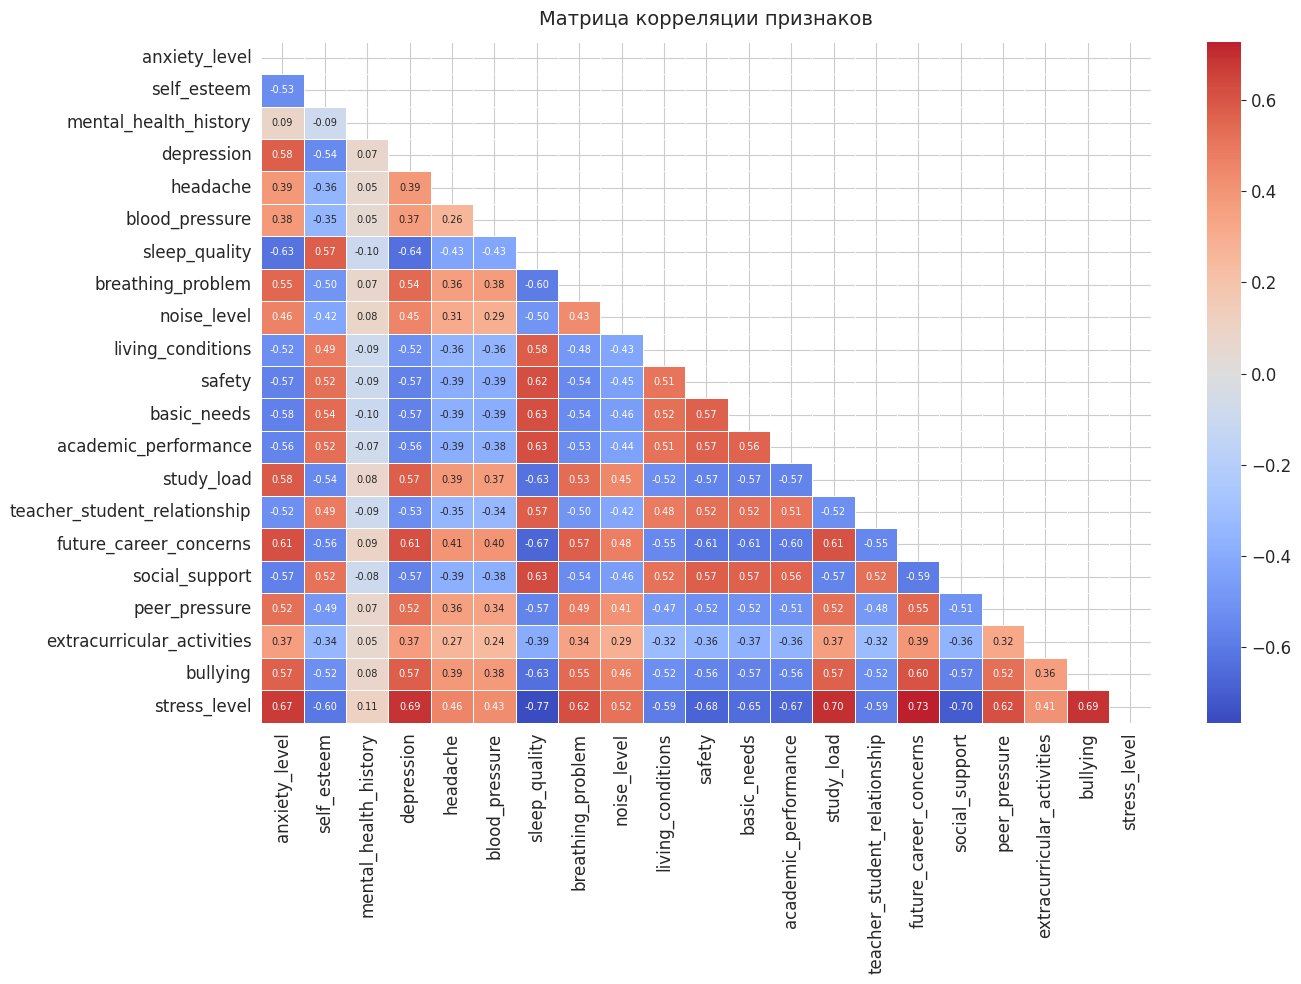

Топ-5 признаков по корреляции с stress_level:
  sleep_quality                       |r| = 0.767
  future_career_concerns              |r| = 0.728
  social_support                      |r| = 0.704
  study_load                          |r| = 0.698
  depression                          |r| = 0.688


In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))  # показываем только нижний треугольник
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.4,
    annot_kws={'size': 7}, ax=ax
)
ax.set_title('Матрица корреляции признаков', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Топ-5 признаков, наиболее коррелирующих с целевой переменной
top_corr = corr['stress_level'].drop('stress_level').abs().sort_values(ascending=False).head(5)
print('Топ-5 признаков по корреляции с stress_level:')
for feat, val in top_corr.items():
    print(f'  {feat:<35} |r| = {val:.3f}')


### 4.4 Анализ выбросов (boxplot)

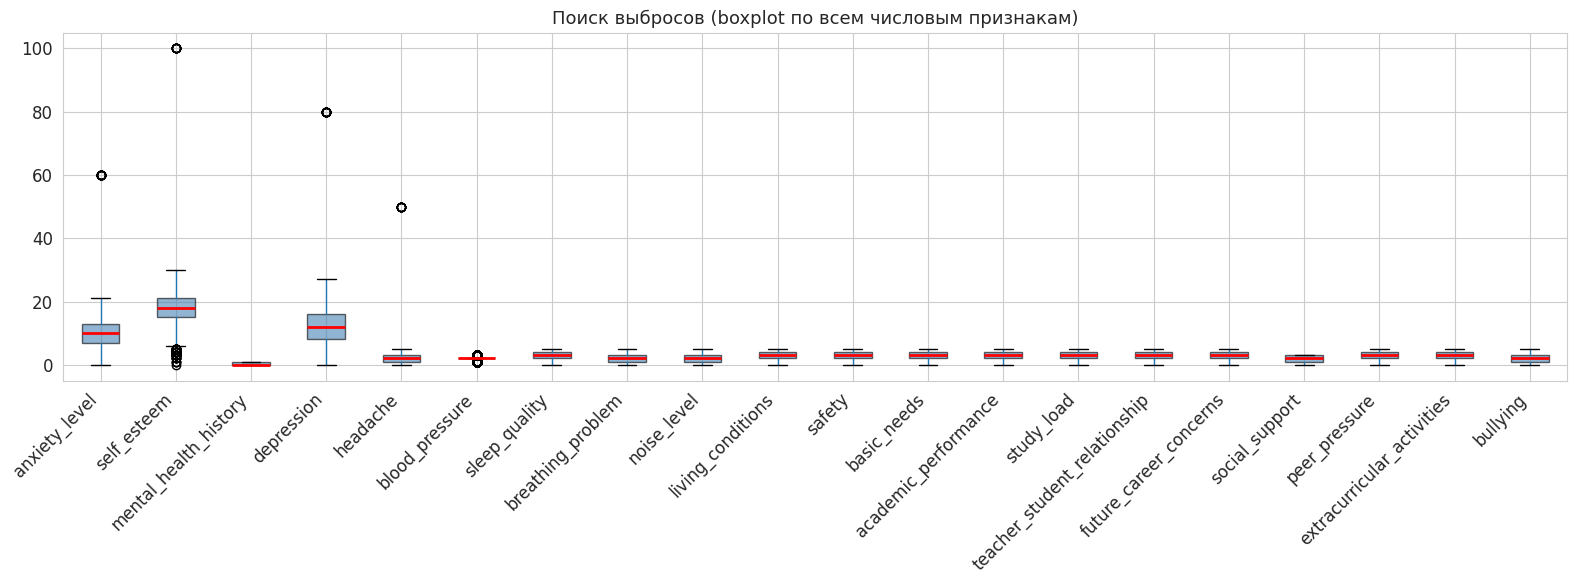

Вывод: выбросы присутствуют в ряде признаков, однако после масштабирования их влияние на линейные модели снижается.


In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
df[num_cols].boxplot(ax=ax, vert=True, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2))
ax.set_title('Поиск выбросов (boxplot по всем числовым признакам)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Вывод: выбросы присутствуют в ряде признаков, однако после масштабирования их влияние на линейные модели снижается.')


### 4.5 Связь ключевых признаков с уровнем стресса

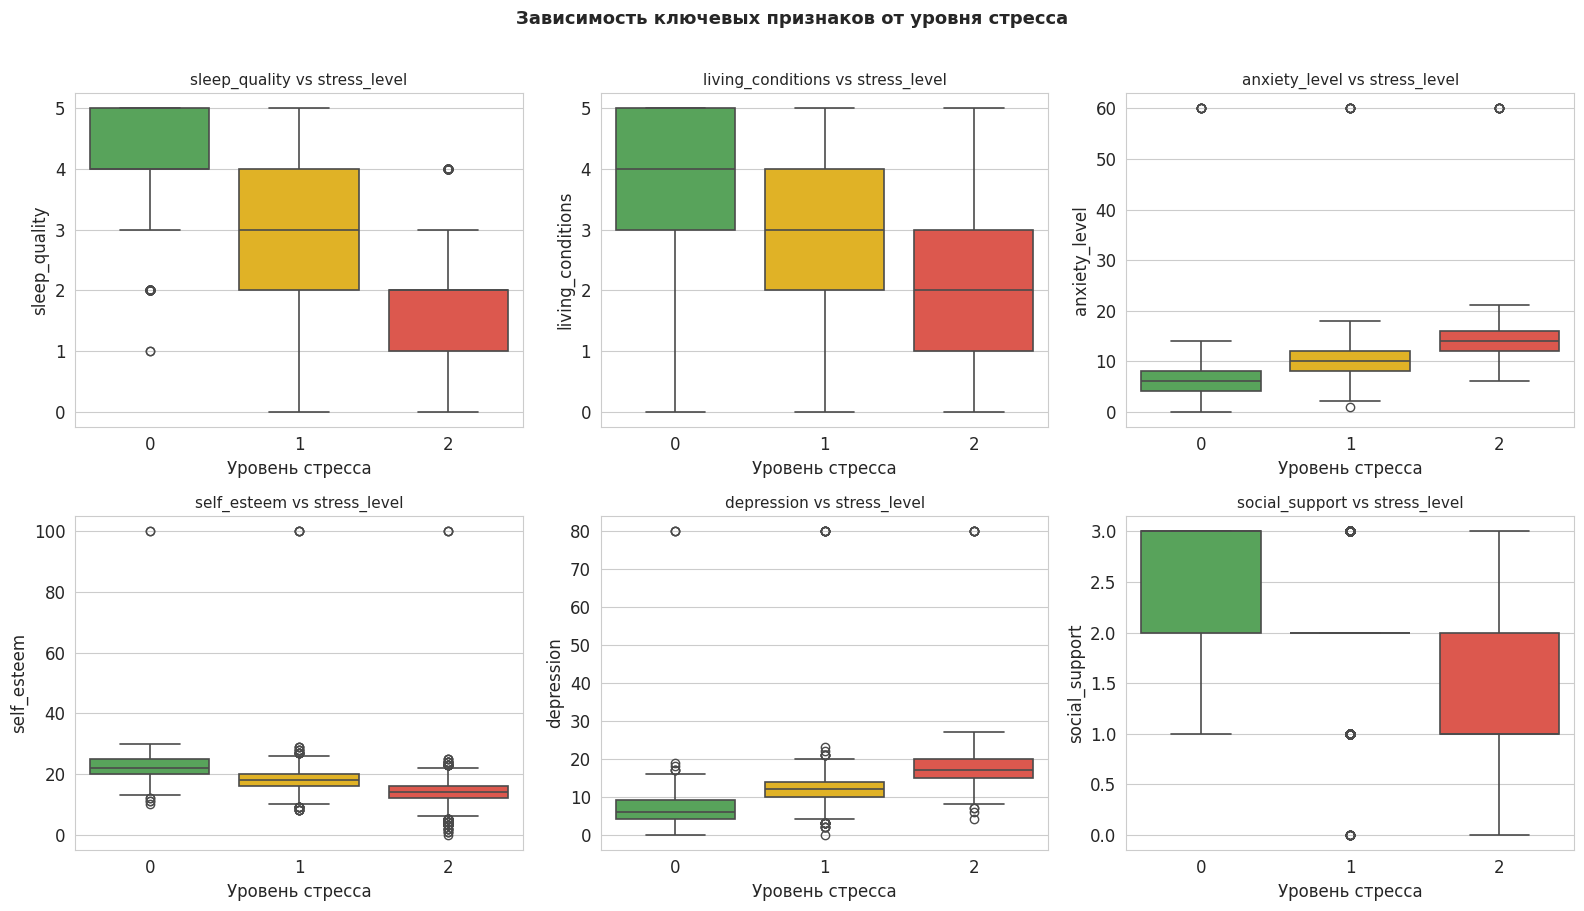

Вывод: sleep_quality и self_esteem убывают с ростом стресса;
anxiety_level и depression — возрастают. Чёткое разделение классов.


In [ ]:
key_features = ['sleep_quality', 'living_conditions', 'anxiety_level',
                 'self_esteem', 'depression', 'social_support']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette_list = ['#4CAF50', '#FFC107', '#F44336']

for i, feat in enumerate(key_features):
    sns.boxplot(
        data=df, x='stress_level', y=feat,
        palette=palette_list, ax=axes[i],
        order=[0, 1, 2], linewidth=1.2
    )
    axes[i].set_title(f'{feat} vs stress_level', fontsize=11)
    axes[i].set_xlabel('Уровень стресса')
    axes[i].set_ylabel(feat)

plt.suptitle('Зависимость ключевых признаков от уровня стресса', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Вывод: sleep_quality и self_esteem убывают с ростом стресса;')
print('anxiety_level и depression — возрастают. Чёткое разделение классов.')


### 4.6 Pairplot по ключевым признакам

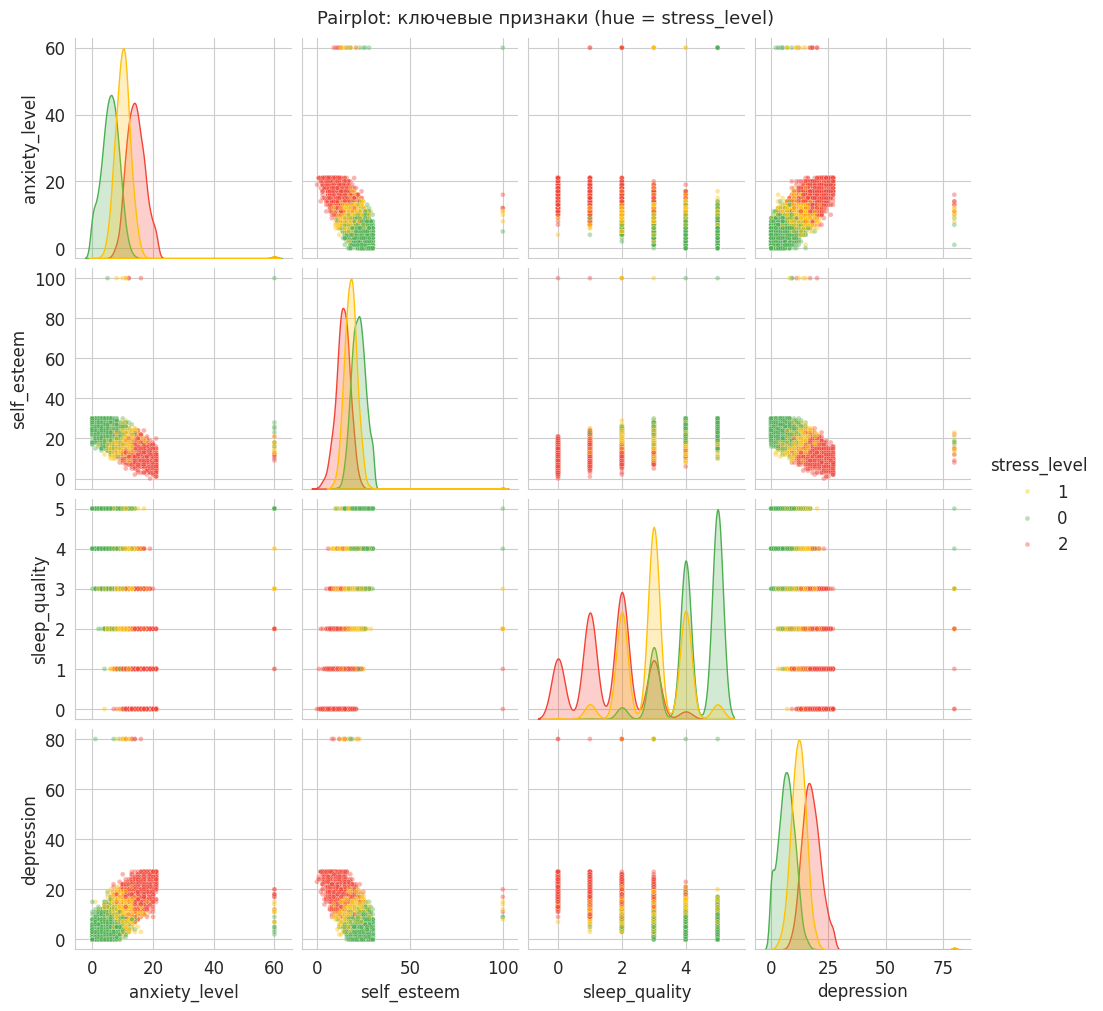

In [ ]:
pairplot_cols = ['anxiety_level', 'self_esteem', 'sleep_quality', 'depression', 'stress_level']
df_pair = df.copy()
df_pair['stress_level'] = df_pair['stress_level'].astype(str)  # строки для hue

palette_str = {'0': '#4CAF50', '1': '#FFC107', '2': '#F44336'}
g = sns.pairplot(
    df_pair[pairplot_cols],
    hue='stress_level',
    palette=palette_str,
    plot_kws={'alpha': 0.4, 's': 12},
    diag_kind='kde'
)
g.figure.suptitle('Pairplot: ключевые признаки (hue = stress_level)', y=1.01, fontsize=13)
plt.show()


## 5. Предобработка данных <a id='5'></a>

Шаги: кодирование категориальных признаков → разделение X/y → стратифицированный train/test split → стандартизация.


In [ ]:
# 5.1 Кодирование категориальных признаков
le = LabelEncoder()
df_enc = df.copy()
cat_cols = df_enc.select_dtypes(include='object').columns.tolist()
print('Категориальные признаки:', cat_cols)
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])
print('Кодирование завершено.')


Категориальные признаки: []
Кодирование завершено.


In [ ]:
# 5.2 Разделение на признаки и целевую переменную
X = df_enc.drop('stress_level', axis=1)
y = df_enc['stress_level']

print(f'Матрица признаков X: {X.shape}')
print(f'Вектор меток y: {y.shape}, классы: {sorted(y.unique())}')


Матрица признаков X: (8365, 20)
Вектор меток y: (8365,), классы: [np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
# 5.3 Стратифицированный train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y   # ← сохраняем пропорции классов в обеих частях
)

print(f'Train: {X_train.shape[0]} объектов')
print(f'Test:  {X_test.shape[0]} объектов')
print()
print('Распределение классов в train:')
print(y_train.value_counts().sort_index().to_string())
print('Распределение классов в test:')
print(y_test.value_counts().sort_index().to_string())


Train: 6692 объектов
Test:  1673 объектов

Распределение классов в train:
stress_level
0    2212
1    2287
2    2193
Распределение классов в test:
stress_level
0    553
1    572
2    548


In [ ]:
# 5.4 Масштабирование (StandardScaler)
# fit ТОЛЬКО на train, transform применяем к обоим — предотвращаем утечку данных (data leakage)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('StandardScaler применён.')
print(f'Среднее по train (первые 3 признака): {X_train_sc.mean(axis=0)[:3].round(4)}')
print(f'Ст. откл. по train (первые 3 признака): {X_train_sc.std(axis=0)[:3].round(4)}')


StandardScaler применён.
Среднее по train (первые 3 признака): [ 0. -0. -0.]
Ст. откл. по train (первые 3 признака): [1. 1. 1.]


## 6. Обучение моделей <a id='6'></a>

Обучаем четыре алгоритма с параметрами по умолчанию (baseline). Все модели используют `random_state=42` там, где это поддерживается.


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'KNN':                 KNeighborsClassifier(),
}

results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    acc   = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f'{name:<25}  Accuracy = {acc:.4f}')


Logistic Regression        Accuracy = 0.8530
Decision Tree              Accuracy = 0.7968
Random Forest              Accuracy = 0.8619
KNN                        Accuracy = 0.8243


## 7. Сравнение моделей и детальные метрики <a id='7'></a>

### 7.1 Сравнительная диаграмма Accuracy

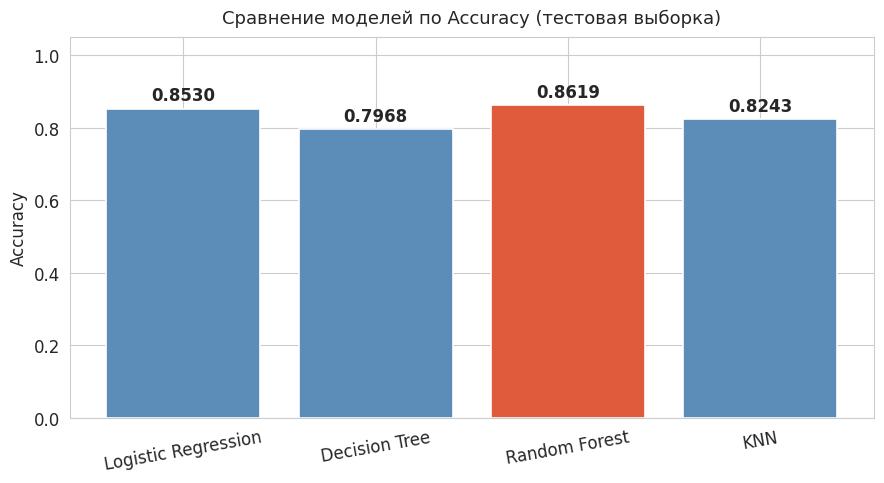

In [ ]:
names  = list(results.keys())
scores = [results[n]['accuracy'] for n in names]
colors_bar = ['#5B8DB8' if n != 'Random Forest' else '#E05B3C' for n in names]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, scores, color=colors_bar, edgecolor='white', linewidth=1.2)
ax.set_ylim(0, 1.05)
ax.set_title('Сравнение моделей по Accuracy (тестовая выборка)', fontsize=13, pad=10)
ax.set_ylabel('Accuracy')
ax.bar_label(bars, fmt='%.4f', padding=3, fontweight='bold')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


### 7.2 Матрицы ошибок (все модели)

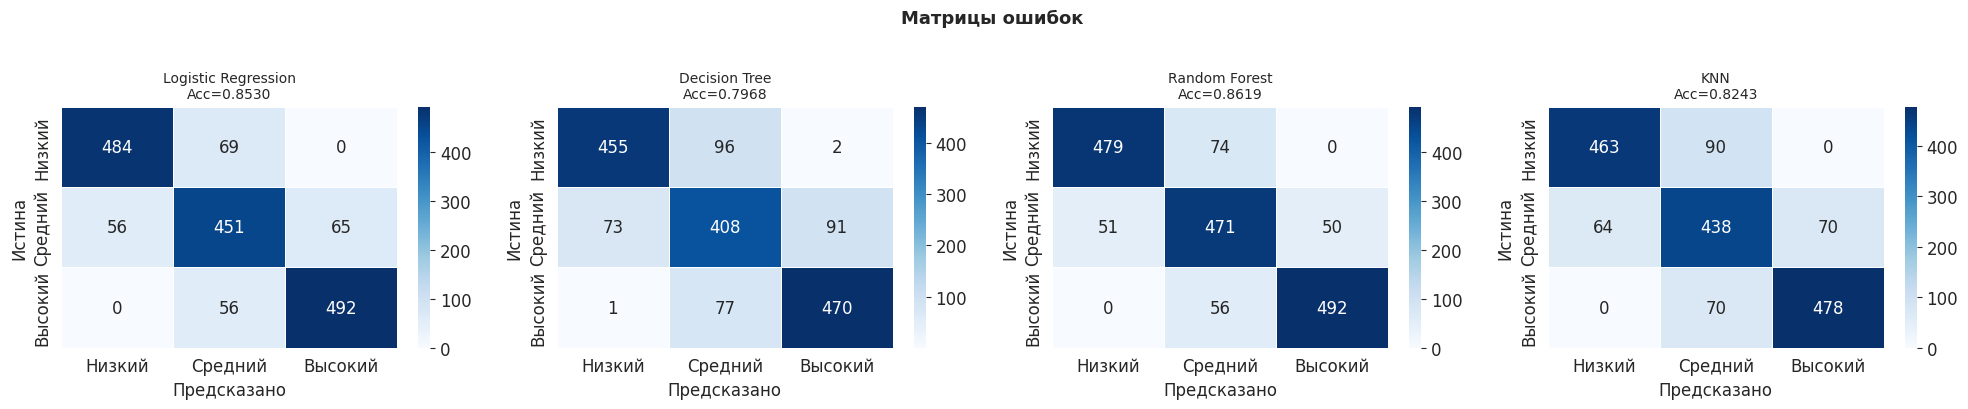

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
class_labels = ['Низкий', 'Средний', 'Высокий']

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        linewidths=0.5, ax=ax
    )
    ax.set_title(f'{name}\nAcc={res["accuracy"]:.4f}', fontsize=10)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истина')

plt.suptitle('Матрицы ошибок', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 7.3 Classification Report — Random Forest

In [ ]:
best_name  = max(results, key=lambda n: results[n]['accuracy'])
best_preds = results[best_name]['preds']
print(f'Лучшая модель: {best_name}')
print()
print(classification_report(
    y_test, best_preds,
    target_names=['Низкий (0)', 'Средний (1)', 'Высокий (2)']
))


Лучшая модель: Random Forest

              precision    recall  f1-score   support

  Низкий (0)       0.90      0.87      0.88       553
 Средний (1)       0.78      0.82      0.80       572
 Высокий (2)       0.91      0.90      0.90       548

    accuracy                           0.86      1673
   macro avg       0.87      0.86      0.86      1673
weighted avg       0.86      0.86      0.86      1673



### 7.4 Сводная таблица метрик

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary_rows = []
for name, res in results.items():
    p = res['preds']
    summary_rows.append({
        'Модель':     name,
        'Accuracy':   round(res['accuracy'], 4),
        'Precision':  round(precision_score(y_test, p, average='weighted', zero_division=0), 4),
        'Recall':     round(recall_score(y_test, p, average='weighted', zero_division=0), 4),
        'F1-score':   round(f1_score(y_test, p, average='weighted', zero_division=0), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Модель')
summary_df = summary_df.sort_values('F1-score', ascending=False)
summary_df.style.highlight_max(axis=0, color='#d4f0c1').format('{:.4f}')


,Accuracy,Precision,Recall,F1-score
Модель,,,,
Random Forest,0.8619,0.8640,0.8619,0.8627
Logistic Regression,0.8530,0.8533,0.8530,0.8531
KNN,0.8243,0.8265,0.8243,0.8251
Decision Tree,0.7968,0.7978,0.7968,0.7971


## 8. Подбор гиперпараметров Random Forest (GridSearchCV) <a id='8'></a>

Улучшаем лучшую модель перебором ключевых гиперпараметров с 5-кратной стратифицированной кросс-валидацией.


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_sc, y_train)

print(f'Лучшие параметры: {grid_search.best_params_}')
print(f'Лучший F1 (CV):   {grid_search.best_score_:.4f}')


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Лучшие параметры: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Лучший F1 (CV):   0.8658


In [ ]:
best_rf    = grid_search.best_estimator_
preds_best = best_rf.predict(X_test_sc)
acc_best   = accuracy_score(y_test, preds_best)

print(f'Accuracy Random Forest (оптимизированный): {acc_best:.4f}')
print()
print(classification_report(
    y_test, preds_best,
    target_names=['Низкий (0)', 'Средний (1)', 'Высокий (2)']
))


Accuracy Random Forest (оптимизированный): 0.8625

              precision    recall  f1-score   support

  Низкий (0)       0.91      0.86      0.88       553
 Средний (1)       0.79      0.82      0.80       572
 Высокий (2)       0.90      0.91      0.91       548

    accuracy                           0.86      1673
   macro avg       0.87      0.86      0.86      1673
weighted avg       0.86      0.86      0.86      1673



## 9. Кросс-валидация лучшей модели <a id='9'></a>

In [ ]:
# Кросс-валидация на ВСЕЙ выборке (X целиком, без лика)
X_all = scaler.fit_transform(X)   # масштабируем всю выборку

cv_scores = cross_val_score(
    RandomForestClassifier(**grid_search.best_params_, random_state=RANDOM_STATE),
    X_all, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy',
    n_jobs=-1
)

print('Accuracy по фолдам:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\nСредняя accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')


Accuracy по фолдам:
  Fold 1: 0.8530
  Fold 2: 0.8595
  Fold 3: 0.8613
  Fold 4: 0.8673
  Fold 5: 0.8739

Средняя accuracy: 0.8630 ± 0.0071


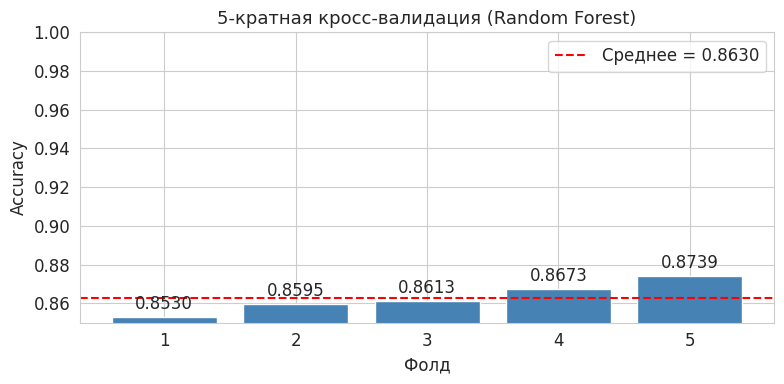

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Среднее = {cv_scores.mean():.4f}')
ax.set_title('5-кратная кросс-валидация (Random Forest)', fontsize=13)
ax.set_xlabel('Фолд')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.85, 1.0)
ax.legend()
ax.bar_label(ax.containers[0], fmt='%.4f', padding=3)
plt.tight_layout()
plt.show()


## 10. Анализ важности признаков <a id='10'></a>

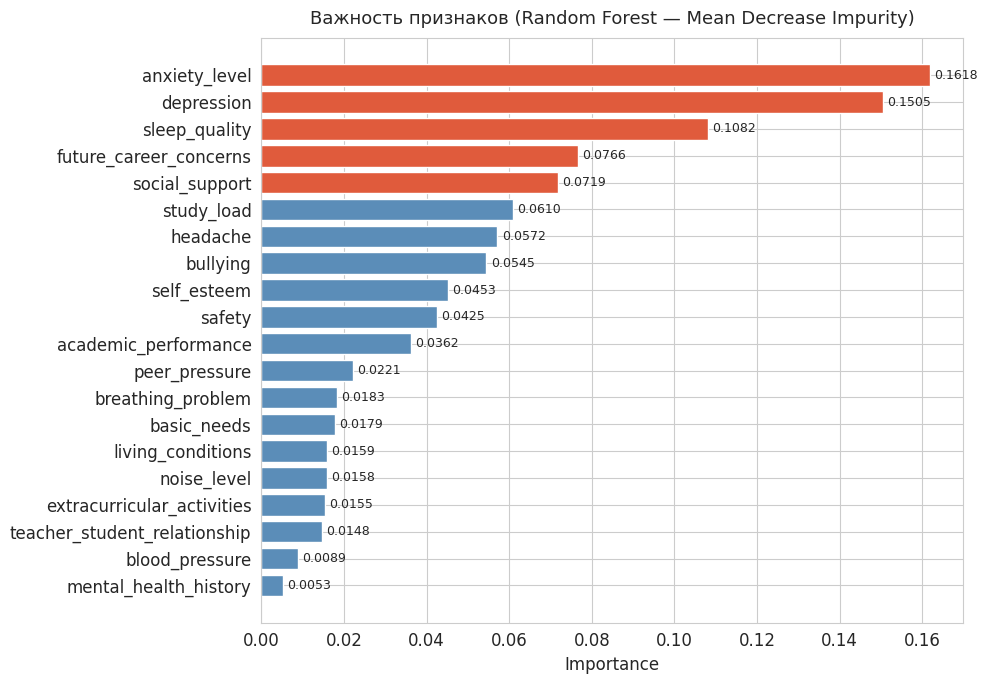

Топ-5 признаков:
               Признак  Важность
         anxiety_level  0.161754
            depression  0.150459
         sleep_quality  0.108170
future_career_concerns  0.076586
        social_support  0.071909


In [ ]:
importances = best_rf.feature_importances_
feat_names  = X.columns.tolist()

feat_df = pd.DataFrame({'Признак': feat_names, 'Важность': importances})
feat_df = feat_df.sort_values('Важность', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    feat_df['Признак'], feat_df['Важность'],
    color=['#E05B3C' if i < 5 else '#5B8DB8' for i in range(len(feat_df))],
    edgecolor='white'
)
ax.invert_yaxis()
ax.set_title('Важность признаков (Random Forest — Mean Decrease Impurity)', fontsize=13, pad=10)
ax.set_xlabel('Importance')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

print('Топ-5 признаков:')
print(feat_df.head(5).to_string(index=False))


## 11. ROC-кривые (One-vs-Rest) <a id='11'></a>

Для многоклассовой задачи строим ROC-кривые по схеме «один против всех» (OvR). AUC близкий к 1 свидетельствует о высокой различимости классов.


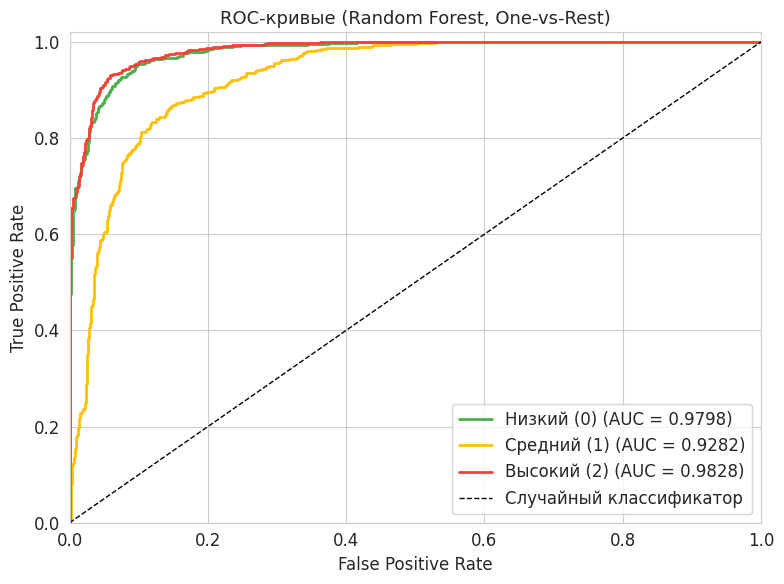

In [ ]:
classes = [0, 1, 2]
class_labels_roc = ['Низкий (0)', 'Средний (1)', 'Высокий (2)']
colors_roc = ['#4CAF50', '#FFC107', '#F44336']

# Получаем вероятности для каждого класса
y_score = best_rf.predict_proba(X_test_sc)
y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls, lbl, col) in enumerate(zip(classes, class_labels_roc, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{lbl} (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Случайный классификатор')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые (Random Forest, One-vs-Rest)', fontsize=13)
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()
